<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 5 - Modelos de Ensambles - Stacking 2025</h3>
    <h3>Ejercicio 3_Sincronico</h3>
        <p>Docente: Rodrigo Del Rosso, Drago Braian, Sebastian Calcagno<p>
</div>  

# 📊 Preprocesamiento de Datos de Consumo y Clima

In [ ]:
!pip install optuna
!pip install catboost
!pip install lightgbm
!pip install xgboost

In [ ]:
import pandas as pd
import requests
from io import BytesIO
import zipfile
# StackingRegressor con Optuna y series temporales
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingRegressor
import optuna
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
np.random.seed(42)

In [ ]:
# URL del archivo ZIP en GitHub
zip_url = 'https://github.com/braiandrago/AST/blob/main/london_energy.csv.zip?raw=true'

# Descargar el archivo ZIP
response = requests.get(zip_url)
if response.status_code == 200:
    # Leer el contenido del archivo ZIP en un objeto BytesIO
    zip_content = BytesIO(response.content)

    # Descomprimir el archivo ZIP y extraer el archivo CSV
    with zipfile.ZipFile(zip_content, 'r') as zip_file:
        csv_file_name = 'london_energy.csv'
        with zip_file.open(csv_file_name) as csv_file:
            # Leer el archivo CSV en un DataFrame
            df_energy = pd.read_csv(csv_file)

    # Mostrar la información del DataFrame
    df_energy.info()
else:
    print("Error al descargar el archivo ZIP")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3510433 entries, 0 to 3510432
Data columns (total 3 columns):
 #   Column  Dtype  
---  ------  -----  
 0   LCLid   object 
 1   Date    object 
 2   KWH     float64
dtypes: float64(1), object(2)
memory usage: 80.3+ MB


In [ ]:
# Agrupar consumo por fecha
df_avg_consumption = df_energy.groupby("Date")["KWH"].mean()
df_avg_consumption = pd.DataFrame({
    "date": df_avg_consumption.index.tolist(),
    "consumption": df_avg_consumption.values.tolist()
})
df_avg_consumption["date"] = pd.to_datetime(df_avg_consumption["date"])
print(f"From: {df_avg_consumption['date'].min()}")
print(f"To: {df_avg_consumption['date'].max()}")

From: 2011-11-23 00:00:00
To: 2014-02-28 00:00:00


In [ ]:
# Crear features temporales
df_avg_consumption["day_of_week"] = df_avg_consumption["date"].dt.dayofweek
df_avg_consumption["day_of_year"] = df_avg_consumption["date"].dt.dayofyear
df_avg_consumption["month"] = df_avg_consumption["date"].dt.month
df_avg_consumption["quarter"] = df_avg_consumption["date"].dt.quarter
df_avg_consumption["year"] = df_avg_consumption["date"].dt.year

In [ ]:
# Cargar datos de clima
url = 'https://raw.githubusercontent.com/braiandrago/AST/main/london_weather.csv'
df_weather = pd.read_csv(url)
print(df_weather.isna().sum())

# Parsear fechas y completar faltantes
df_weather["date"] = pd.to_datetime(df_weather["date"], format="%Y%m%d")
df_weather = df_weather.ffill()

date                   0
cloud_cover           19
sunshine               0
global_radiation      19
max_temp               6
mean_temp             36
min_temp               2
precipitation          6
pressure               4
snow_depth          1441
dtype: int64


In [ ]:
# Unir datasets
df = df_avg_consumption.merge(df_weather, how="inner", on="date")

# Crear variables rezagadas
df["consumption_lag_1"] = df["consumption"].shift(1)
df["consumption_lag_2"] = df["consumption"].shift(2)
df["consumption_lag_3"] = df["consumption"].shift(3)

# Eliminar filas con NaN
df.dropna(inplace=True)

In [ ]:
# Mostrar resultado final
df.head()

,date,consumption,day_of_week,day_of_year,month,quarter,year,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth,consumption_lag_1,consumption_lag_2,consumption_lag_3
3,2011-11-26,10.267707,5,330,11,4,2011,4.0,0.7,24.0,13.9,10.2,6.3,0.0,102580.0,0.0,9.499781,8.536480,6.952692
4,2011-11-27,10.850805,6,331,11,4,2011,3.0,5.9,55.0,13.2,11.8,9.7,0.0,102130.0,0.0,10.267707,9.499781,8.536480
5,2011-11-28,9.103382,0,332,11,4,2011,5.0,0.0,15.0,13.9,6.7,0.2,0.0,102270.0,0.0,10.850805,10.267707,9.499781
6,2011-11-29,9.274873,1,333,11,4,2011,6.0,0.0,15.0,12.8,8.6,3.3,0.4,100960.0,0.0,9.103382,10.850805,10.267707
7,2011-11-30,8.813513,2,334,11,4,2011,4.0,3.7,42.0,11.0,9.2,5.5,1.2,101920.0,0.0,9.274873,9.103382,10.850805


# 📊 Adecuación entrenamiento

In [ ]:
# 1. Setting features & target

features = ['day_of_week', 'day_of_year', 'month', 'quarter', 'year', 'cloud_cover',
            'sunshine', 'global_radiation', 'max_temp', 'mean_temp', 'min_temp',
            'precipitation', 'pressure', 'snow_depth', 'consumption_lag_1',
            'consumption_lag_2', 'consumption_lag_3']
target = 'consumption'

X = df[features]
y = df[target]

**Optimización de hiperparámetros con Optuna**  
Se define una función objective_factory() que crea la función objetivo para cada modelo.

Se optimiza cada modelo con 30 trials usando mean_squared_error como métrica.

Se optimizan:

-CatBoostRegressor  
-RandomForestRegressor  
-LGBMRegressor  
-XGBRegressor  

In [ ]:
# 2. Create TimeSeriesSplit object here to ensure it's defined in this cell
tscv = TimeSeriesSplit(n_splits=5)

# 3. Optuna para cada modelo
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_results = {}

# Funciones objetivo Optuna con validación cruzada temporal
def objective_factory(model_class, param_suggester, tscv_splitter, X_data, y_data):
    def objective(trial):
        params = param_suggester(trial)
        model = model_class(**params)
        scores = []
        # Use TimeSeriesSplit for temporal cross-validation
        for train_idx, val_idx in tscv_splitter.split(X_data):
            X_train_fold, X_val_fold = X_data.iloc[train_idx], X_data.iloc[val_idx]
            y_train_fold, y_val_fold = y_data.iloc[train_idx], y_data.iloc[val_idx]

            model.fit(X_train_fold, y_train_fold)
            preds = model.predict(X_val_fold)
            scores.append(mean_squared_error(y_val_fold, preds))
        # Return the average score across all folds
        return np.mean(scores)
    return objective

# Define hyperparameter search spaces (already defined in previous cell, kept here for context)
param_spaces = {
    'catboost': lambda trial: {
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'iterations': trial.suggest_int('iterations', 100, 500),
        'verbose': 0,
        'random_seed': 42, # Add random_seed for reproducibility
        'allow_writing_files': False # Prevent writing files
    },
    'rf': lambda trial: {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 4, 15),
        'random_state': 42 # Add random_state for reproducibility
    },
    'lgbm': lambda trial: {
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'random_state': 42 # Add random_state for reproducibility
    },
    'xgb': lambda trial: {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'random_state': 42 # Add random_state for reproducibility
    }
}

# Model classes dictionary (already defined in previous cell, kept here for context)
model_classes = {
    'catboost': CatBoostRegressor,
    'rf': RandomForestRegressor,
    'lgbm': LGBMRegressor,
    'xgb': XGBRegressor
}


# Iterate through models, create study, and optimize
for name in model_classes:
    print(f"Running Optuna optimization for {name}...")
    objective = objective_factory(model_classes[name], param_spaces[name], tscv, X, y)
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=30) # Run 30 trials for optimization
    study_results[name] = study
    print(f"Finished optimization for {name}. Best MSE: {study.best_value:.4f}")

print("\nOptuna optimization complete for all base models.")

Se han truncado las últimas 5000 líneas del flujo de salida.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

**Stacking**  
Es una técnica de ensamble que combina múltiples modelos (también llamados estimadores base) para mejorar la predicción final. En lugar de hacer un simple promedio o votación como en bagging o boosting, Stacking aprende cómo combinar los modelos base usando otro modelo, llamado meta-modelo o modelo final.

*passthrough=True:* El meta-modelo también recibe las features originales además de las predicciones de los modelos base. Esto suele mejorar el rendimiento.

Supongamos que tres modelos realizan las siguientes predicciones:

* **Random Forest:** 950
* **LightGBM:** 980
* **Regresión lineal:** 920

Un ensamble simple por promedio calcularía:

$$
\hat{y} = \frac{950 + 980 + 920}{3} = 950
$$

En cambio, el **stacking** no necesariamente promedia las predicciones. Las utiliza como nuevas variables de entrada para otro modelo, denominado **meta-modelo** o **modelo final**.

La estructura básica sería:

```text
Random Forest       → 950 ─┐
LightGBM            → 980 ─┼──→ Meta-modelo ──→ Predicción final
Regresión lineal    → 920 ─┘
```

El meta-modelo aprende cómo combinar las predicciones de los modelos base.

Por ejemplo, podría aprender que:

* **LightGBM** suele funcionar mejor durante períodos de alta volatilidad.
* La **regresión lineal** funciona mejor cuando existe una tendencia estable.
* **Random Forest** funciona mejor cuando aparecen determinadas combinaciones no lineales entre las variables.

Los pesos no tienen que ser definidos manualmente. Son aprendidos por el meta-modelo a partir de los datos de entrenamiento.

---

## Uso de `passthrough=True`

Normalmente, el meta-modelo recibe únicamente las predicciones generadas por los modelos base:

```text
Predicción Random Forest
Predicción LightGBM
Predicción Regresión lineal
```

Cuando se utiliza:

```python
passthrough=True
```

el meta-modelo recibe tanto las predicciones de los modelos base como las variables originales del problema.

la estructura completa sería:

```text
Variables originales ──→ Random Forest ────────┐
                     ├─→ LightGBM ──────────────┤
                     └─→ Regresión lineal ──────┤
                                                ├──→ Meta-modelo
Variables originales ───────────────────────────┘
```

Por lo tanto, el meta-modelo recibe:

Esto permite que el meta-modelo aprenda reglas más contextuales.

Por ejemplo:

```text
Si la volatilidad es alta:
    confiar más en LightGBM.

Si la serie presenta una tendencia estable:
    confiar más en la regresión lineal.

Si aparecen relaciones no lineales entre las variables:
    confiar más en Random Forest.
```

Sin `passthrough=True`, el meta-modelo solamente observa las predicciones:

```text
[950, 980, 920]
```

Con `passthrough=True`, también observa el contexto en el cual fueron realizadas:

En términos conceptuales:

* Con `passthrough=False`, el meta-modelo aprende **qué modelo suele ser mejor**.
* Con `passthrough=True`, el meta-modelo puede aprender **qué modelo funciona mejor bajo determinadas condiciones**.


In [ ]:
# 4. Modelos finales
cat_model = CatBoostRegressor(**study_results['catboost'].best_params, verbose=0)
rf_model = RandomForestRegressor(**study_results['rf'].best_params)
lgbm_model = LGBMRegressor(**study_results['lgbm'].best_params)
xgb_model = XGBRegressor(**study_results['xgb'].best_params)

# Fit final con todo el conjunto de entrenamiento (último fold)
# Redefine tscv to ensure it's available in this cell
tscv = TimeSeriesSplit(n_splits=5)
last_train_idx, test_idx = list(tscv.split(X))[-1]
X_train, X_test = X.iloc[last_train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[last_train_idx], y.iloc[test_idx]

stack = StackingRegressor(
    estimators=[
        ('cat', cat_model),
        ('rf', rf_model),
        ('lgbm', lgbm_model),
        ('xgb', xgb_model)
    ],
    final_estimator=XGBRegressor(),
    passthrough=True
)

print("Fitting the StackingRegressor...")
stack.fit(X_train, y_train)
print("StackingRegressor fitting complete.")

y_pred = stack.predict(X_test)

Fitting the StackingRegressor...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000078 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1959
[LightGBM] [Info] Number of data points in the train set: 689, number of used features: 16
[LightGBM] [Info] Start training from score 10.229709
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further split

MAE: 0.33
RMSE: 0.94
R2: 0.40


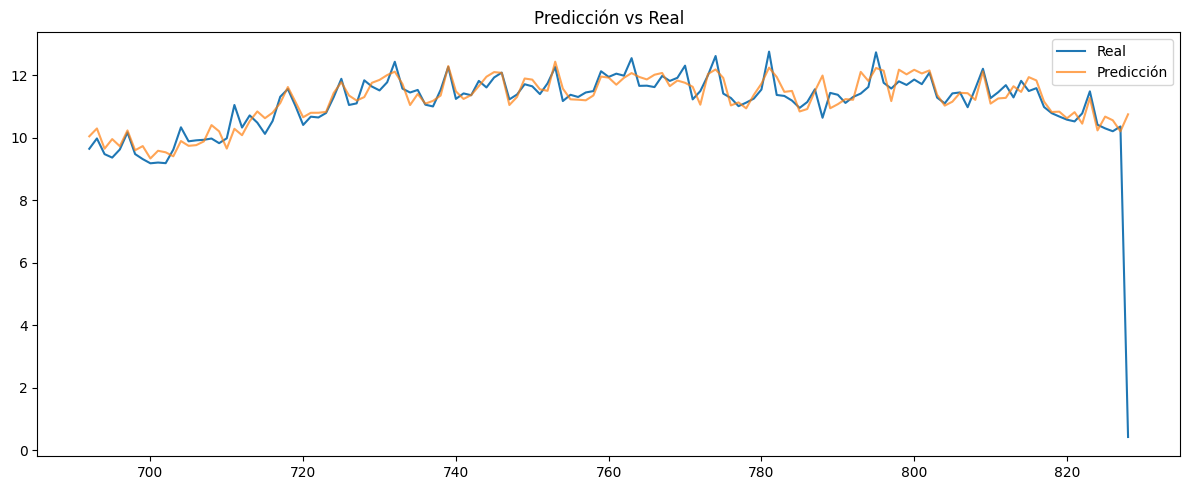

In [ ]:
# 5. Métricas y visualización
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.2f}")

plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test.values, label='Real')
plt.plot(y_test.index, y_pred, label='Predicción', alpha=0.7)
plt.title("Predicción vs Real")
plt.legend()
plt.tight_layout()
plt.show()

# "Entrenamiento con Stacking y validación sin data leakage"

🚨 El modelo anterior pareciera tener un buen performance...pero....

⚠️ Estámos "reusando" datos de validación como test, es decir que estamos evaluando el modelo en datos que influyeron en su ajuste (el último bloque).

🛠️ Esto implica que el meta-modelo aprende indirectamente sobre ese test y por lo tanto el error en test estará sesgado a la baja.  
📊 De esta manera las métricas finales no reflejan el rendimiento real

💡 A continuación correremos nuevamente el modelo seprando una porción (10%) para testeo final del modelo de stacking

In [ ]:
# 1. Separar el conjunto de test final (10%) para evitar data leakage
h = int(len(X) * 0.1)
X_model, X_test = X.iloc[:-h], X.iloc[-h:]
y_model, y_test = y.iloc[:-h], y.iloc[-h:]

# 2. TimeSeriesSplit para tuning sin usar el test
tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
# 3. Optuna para cada modelo
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_results = {}

# Funciones objetivo Optuna con validación cruzada temporal
def objective_factory(model_class, param_suggester, tscv_splitter, X_data, y_data):
    def objective(trial):
        params = param_suggester(trial)
        model = model_class(**params)
        scores = []
        # Use TimeSeriesSplit for temporal cross-validation
        for train_idx, val_idx in tscv_splitter.split(X_data):
            X_train_fold, X_val_fold = X_data.iloc[train_idx], X_data.iloc[val_idx]
            y_train_fold, y_val_fold = y_data.iloc[train_idx], y_data.iloc[val_idx]

            model.fit(X_train_fold, y_train_fold)
            preds = model.predict(X_val_fold)
            scores.append(mean_squared_error(y_val_fold, preds))
        # Return the average score across all folds
        return np.mean(scores)
    return objective


# Define hyperparameter search spaces (already defined in previous cell, kept here for context)
param_spaces = {
    'catboost': lambda trial: {
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'iterations': trial.suggest_int('iterations', 100, 500),
        'verbose': 0,
        'random_seed': 42, # Add random_seed for reproducibility
        'allow_writing_files': False # Prevent writing files
    },
    'rf': lambda trial: {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 4, 15),
        'random_state': 42 # Add random_state for reproducibility
    },
    'lgbm': lambda trial: {
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'random_state': 42 # Add random_state for reproducibility
    },
    'xgb': lambda trial: {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'random_state': 42 # Add random_state for reproducibility
    }
}

# Model classes dictionary (already defined in previous cell, kept here for context)
model_classes = {
    'catboost': CatBoostRegressor,
    'rf': RandomForestRegressor,
    'lgbm': LGBMRegressor,
    'xgb': XGBRegressor
}


# Iterate through models, create study, and optimize
for name in model_classes:
    print(f"Running Optuna optimization for {name}...")
    objective = objective_factory(model_classes[name], param_spaces[name], tscv, X_model, y_model) #aqui seleccionamos con lo que queremos entrenar
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=30) # Run 30 trials for optimization
    study_results[name] = study
    print(f"Finished optimization for {name}. Best MSE: {study.best_value:.4f}")

print("\nOptuna optimization complete for all base models.")

Se han truncado las últimas 5000 líneas del flujo de salida.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

In [ ]:
# 4. Instanciar modelos con mejores hiperparámetros
gb_model = XGBRegressor(**study_results['xgb'].best_params)
cat_model = CatBoostRegressor(**study_results['catboost'].best_params, verbose=0)
rf_model = RandomForestRegressor(**study_results['rf'].best_params)
lgbm_model = LGBMRegressor(**study_results['lgbm'].best_params)

# Entrenar modelo stacking sobre todo X_model
stack = StackingRegressor(
    estimators=[
        ('cat', cat_model),
        ('rf', rf_model),
        ('lgbm', lgbm_model),
        ('xgb', gb_model)
    ],
    final_estimator=XGBRegressor(),
    passthrough=True
)

print("Entrenando modelo Stacking...")
stack.fit(X_model, y_model)
print("Entrenamiento completo.")

Entrenando modelo Stacking...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000229 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2093
[LightGBM] [Info] Number of data points in the train set: 744, number of used features: 16
[LightGBM] [Info] Start training from score 10.266365
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth


Evaluación final sobre test reservado:
MAE: 0.42
RMSE: 1.22
R2: 0.14


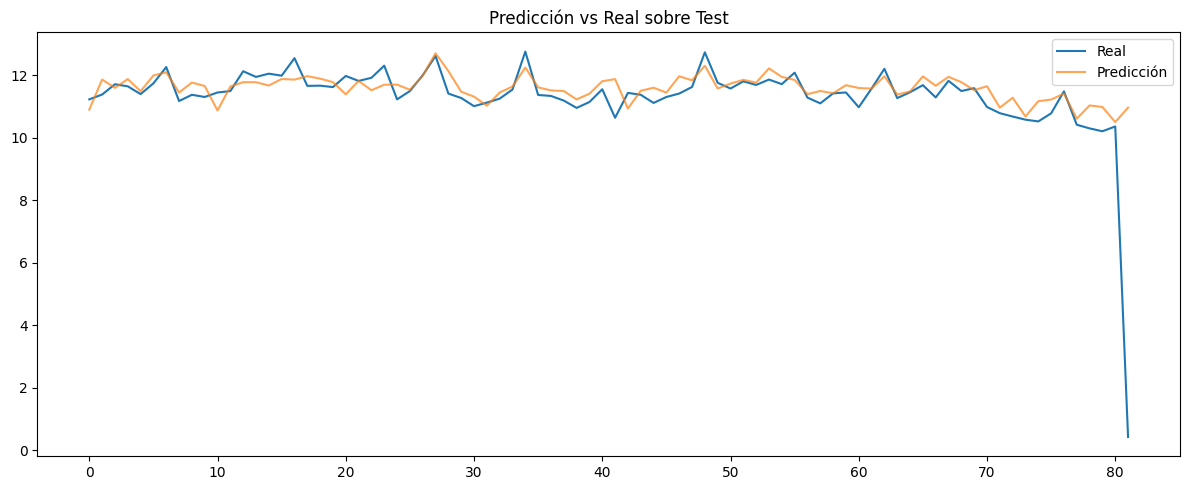

In [ ]:
# 5. Predicción y evaluación sobre test final
y_pred = stack.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nEvaluación final sobre test reservado:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.2f}")

plt.figure(figsize=(12, 5))
plt.plot(y_test.reset_index(drop=True), label='Real')
plt.plot(pd.Series(y_pred), label='Predicción', alpha=0.7)
plt.title("Predicción vs Real sobre Test")
plt.legend()
plt.tight_layout()
plt.show()